In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from src.nn_models.transformer import FTTransformer
from src.nn_models.mlp import MLP
from src.trainer import TrainerModel
from src.nn_models.resnet import ResNet
from src.nn_models.mlp_encoder_transformer import MlpEncoderTransformer
from catboost import CatBoostClassifier
from src.prepare_dataset import PrepareTabularData

## SAINT

In [3]:
import pandas as pd

df = pd.read_csv("data/first_dataset/application_train.csv")
df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_ID_PUBLISH", "SK_ID_CURR"], inplace=True)

df.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(df, test_size=0.3, random_state=42)
validation, test = train_test_split(temp, test_size=0.5, random_state=42)

train['split_column'] = 'train'
validation['split_column'] = 'validation'
test['split_column'] = 'test'

df = pd.concat([train, validation, test]).sort_index()

In [5]:
df.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,split_column
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,validation
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,train
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,validation
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,train
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,validation


In [6]:
from pytorch_lightning import Trainer

from lit_saint import SaintDatamodule, Saint, SaintConfig, SaintTrainer

In [7]:
data_module = SaintDatamodule(df=df, target="TARGET", split_column="split_column")

The following cols will not be used because they have a not supported data type:  []


In [8]:
saint_cfg = SaintConfig()

In [9]:
model = Saint(
    categories=data_module.categorical_dims, 
    continuous=data_module.numerical_columns,
    config=saint_cfg, 
    dim_target=data_module.dim_target
)

In [10]:
pretrainer = Trainer(max_epochs=1)
trainer = Trainer(max_epochs=15)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/tsarevivan/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [11]:
saint_trainer = SaintTrainer(pretrainer=pretrainer, trainer=trainer)

In [12]:
saint_trainer.fit(model=model, datamodule=data_module, enable_pretraining=False)


  | Name                  | Type              | Params
------------------------------------------------------------
0 | embedding_continuos   | ModuleList        | 123 K 
1 | embedding_categorical | Embedding         | 1.6 K 
2 | transformer           | RowColTransformer | 11.7 K
3 | mlp1                  | SepMLP            | 17.1 K
4 | mlp2                  | SepMLP            | 61.3 K
5 | pt_mlp                | SimpleMLP         | 2.5 M 
6 | pt_mlp2               | SimpleMLP         | 2.5 M 
7 | mlpfory               | SimpleMLP         | 241   
------------------------------------------------------------
5.2 M     Trainable params
0         Non-trainable params
5.2 M     Total params
20.928    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/Users/tsarevivan/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/tsarevivan/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


In [14]:
import numpy as np

prediction = saint_trainer.predict(model=model, datamodule=data_module, df=test)

/Users/tsarevivan/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, predict_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Predicting: 841it [00:00, ?it/s]

In [15]:
test["prediction"] = prediction['prediction']

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_score(test["TARGET"], test["prediction"])

0.7433767431690492

### MlpEncoder

In [71]:
# Usage example
model_config = {
    'tf_dropout_rates': [0.1]*6,
    'ff_dropout_rates': [0.1]*6,
    'embedding_dim': 12,
    'num_transformer_blocks': 6,
    'num_heads': 3,
    'mlp_dropout_rates': [0.1, 0.1],
    'mlp_hidden_units_factors': [2, 1]
}

model = TabTransformer(
    categorical_features=categorical_features,
    numerical_features=numerical_features,
    lookup_layers=lookup_layers,
    **model_config
)

NameError: name 'TabTransformer' is not defined

# Gradient Boosting

## First dataset

In [10]:
catboost_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    type_model="Boosting"
)

In [11]:
catboost_data.load_data()

Data downloaded successfully in the amount of 307511


In [12]:
catboost_dataset = catboost_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [13]:
catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=False
)

In [14]:
catboost_trainer = TrainerModel(
    model=catboost, 
    dataset=catboost_dataset, 
    exp_name="catboost", 
    type_model="Boosting"
)

In [15]:
catboost_trainer.train()

Train ROC-AUC: 0.7746 
Train GINI: 0.5492 
Validate ROC-AUC: 0.7701 
Validate GINI: 0.5402 



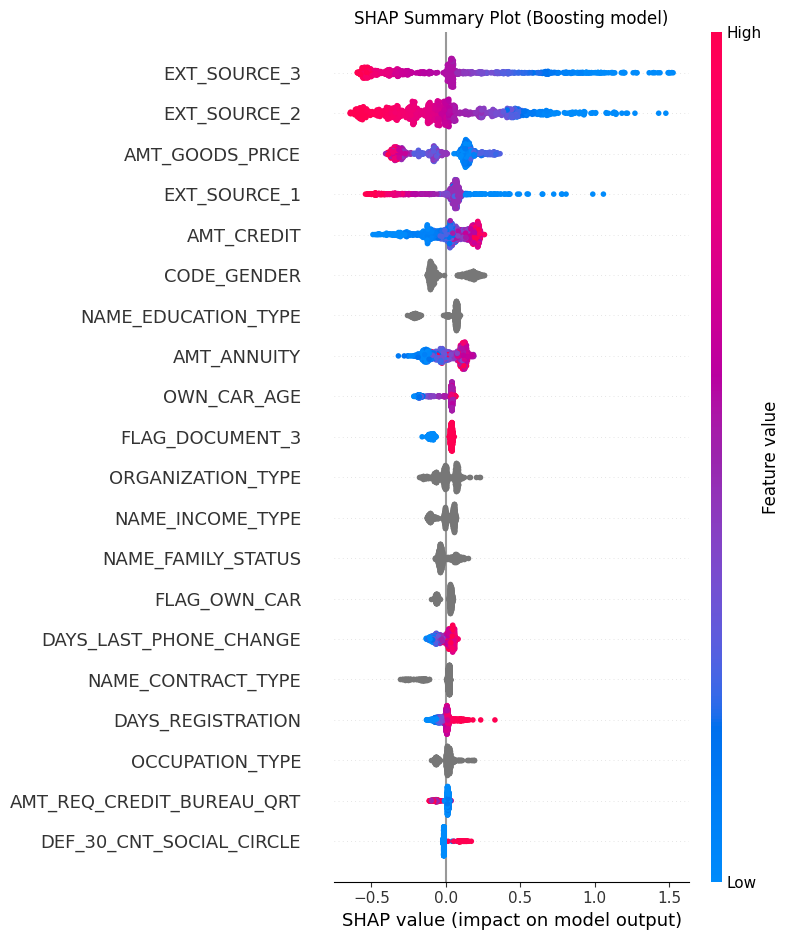

In [30]:
catboost_trainer.plot_shap_summary(df_part='val', sample_size=1000)

## Second dataset

In [143]:
catboost_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    type_model="Boosting"
)

In [144]:
catboost_data.load_data()

Data downloaded successfully in the amount of 51685


In [145]:
catboost_dataset = catboost_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [146]:
catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=False
)

In [147]:
catboost_trainer = TrainerModel(
    model=catboost, 
    dataset=catboost_dataset, 
    exp_name="catboost", 
    type_model="Boosting"
)

In [148]:
catboost_trainer.train()

Train ROC-AUC: 0.9786 
Train GINI: 0.9572 
Validate ROC-AUC: 0.9513 
Validate GINI: 0.9025 



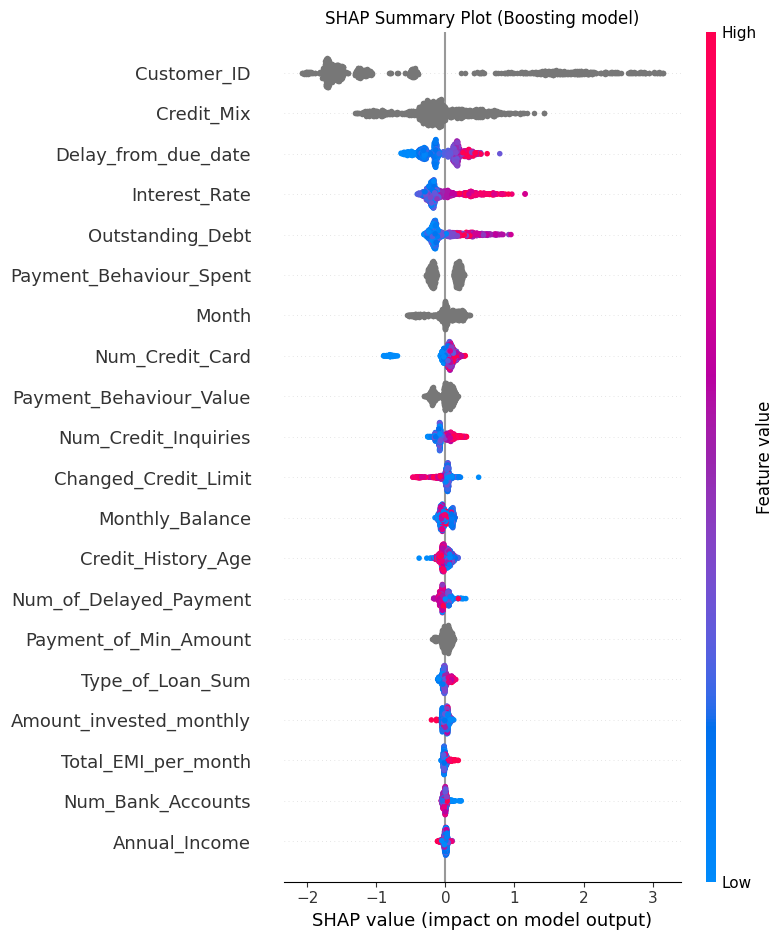

In [149]:
catboost_trainer.plot_shap_summary(df_part='val', sample_size=1000)

# Neural Networks

## MLP

### First Dataset

In [9]:
mlp_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    num_encoder="ple"
)

In [10]:
mlp_data.load_data()

Data downloaded successfully in the amount of 307511


In [11]:
mlp_dataset = mlp_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [12]:
dimensions = mlp_data.torch_tensors_dimensions()
dimensions

(1300, 248)

In [13]:
mlp = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [14]:
mlp_trainer = TrainerModel(
    model=mlp, 
    dataset=mlp_dataset, 
    exp_name="mlp", 
    type_model="NN"
)

In [15]:
mlp_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7377 Train Loss: 0.2816
   Test ROC-AUC: 0.7368 Test Loss: 0.2828
2) Train ROC-AUC: 0.7424 Train Loss: 0.2566
   Test ROC-AUC: 0.74 Test Loss: 0.258
3) Train ROC-AUC: 0.7433 Train Loss: 0.2592
   Test ROC-AUC: 0.7408 Test Loss: 0.2606
4) Train ROC-AUC: 0.7449 Train Loss: 0.2608
   Test ROC-AUC: 0.7418 Test Loss: 0.2622
5) Train ROC-AUC: 0.7457 Train Loss: 0.2579
   Test ROC-AUC: 0.7418 Test Loss: 0.2595
6) Train ROC-AUC: 0.7455 Train Loss: 0.258
   Test ROC-AUC: 0.7423 Test Loss: 0.2593
7) Train ROC-AUC: 0.7455 Train Loss: 0.2589
   Test ROC-AUC: 0.742 Test Loss: 0.2604
8) Train ROC-AUC: 0.746 Train Loss: 0.2592
   Test ROC-AUC: 0.7415 Test Loss: 0.2608
9) Train ROC-AUC: 0.7466 Train Loss: 0.2594
   Test ROC-AUC: 0.7433 Test Loss: 0.2607
10) Train ROC-AUC: 0.7474 Train Loss: 0.2588
   Test ROC-AUC: 0.7432 Test Loss: 0.2604
11) Train ROC-AUC: 0.7463 Train Loss: 0.2561
   Test ROC-AUC: 0.742 Test Loss: 0.2579
12) Train ROC-AUC: 0.7452 Train Loss: 0.2585
   Test ROC-AU

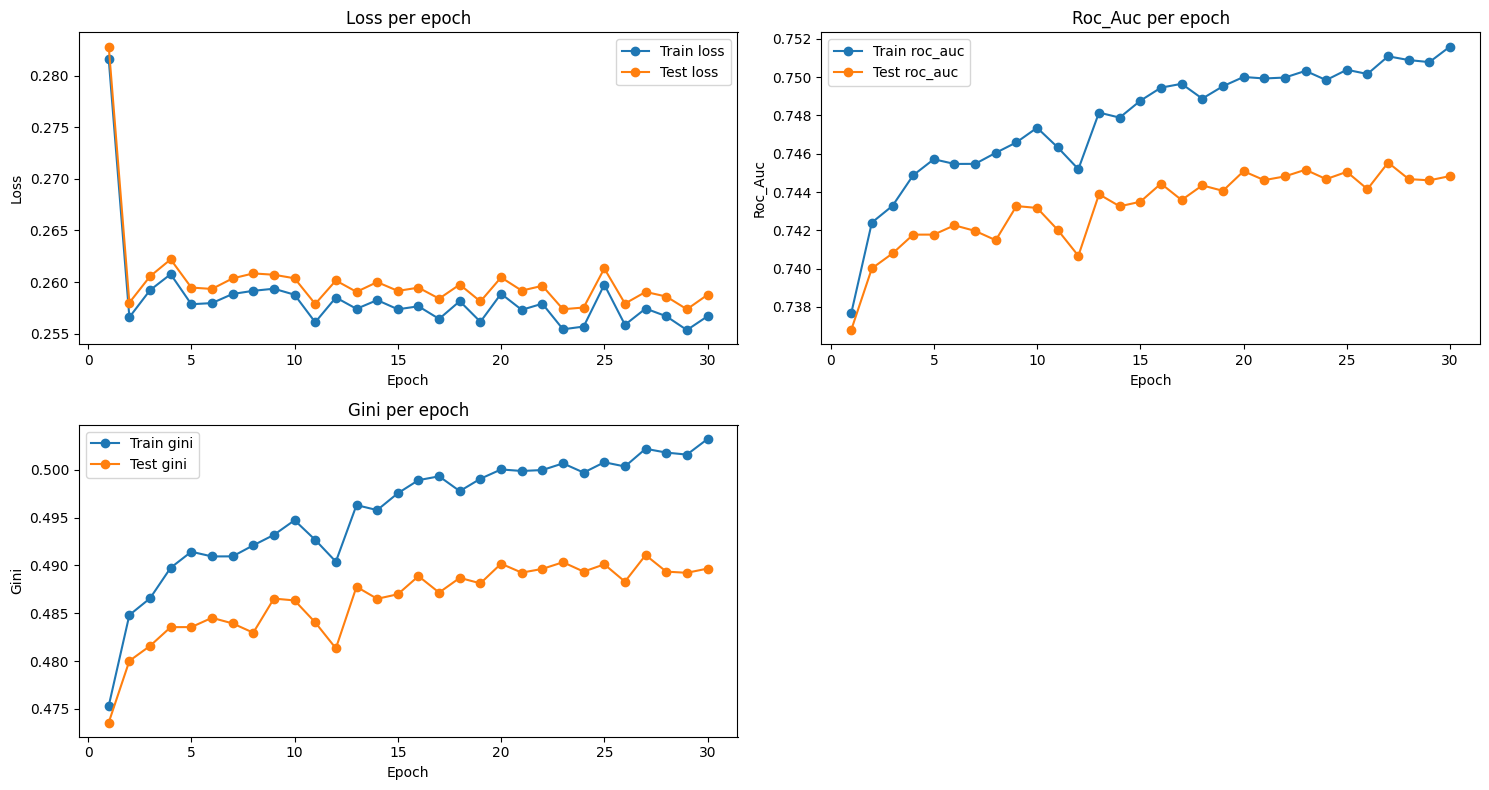

In [16]:
mlp_trainer.get_metrics_graphic()

In [17]:
roc_auc, avg_loss = mlp_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.752


### Second Dataset

In [14]:
mlp_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    num_encoder="ple"
)

In [15]:
mlp_data.load_data()

Data downloaded successfully in the amount of 51685


In [16]:
mlp_dataset = mlp_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [17]:
dimensions = mlp_data.torch_tensors_dimensions()
dimensions

(500, 11709)

In [18]:
mlp = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [19]:
mlp_trainer = TrainerModel(
    model=mlp, 
    dataset=mlp_dataset, 
    exp_name="mlp", 
    type_model="NN"
)

In [20]:
mlp_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7919 Train Loss: 0.4823
   Test ROC-AUC: 0.7874 Test Loss: 0.4881
2) Train ROC-AUC: 0.8164 Train Loss: 0.4759
   Test ROC-AUC: 0.8108 Test Loss: 0.4819
3) Train ROC-AUC: 0.8213 Train Loss: 0.444
   Test ROC-AUC: 0.8155 Test Loss: 0.4534
4) Train ROC-AUC: 0.8294 Train Loss: 0.4341
   Test ROC-AUC: 0.8218 Test Loss: 0.4462
5) Train ROC-AUC: 0.8404 Train Loss: 0.4418
   Test ROC-AUC: 0.8306 Test Loss: 0.4521
6) Train ROC-AUC: 0.8528 Train Loss: 0.4254
   Test ROC-AUC: 0.8425 Test Loss: 0.4374
7) Train ROC-AUC: 0.8674 Train Loss: 0.4128
   Test ROC-AUC: 0.8542 Test Loss: 0.4278
8) Train ROC-AUC: 0.8734 Train Loss: 0.4052
   Test ROC-AUC: 0.8592 Test Loss: 0.4225
9) Train ROC-AUC: 0.8824 Train Loss: 0.3933
   Test ROC-AUC: 0.8676 Test Loss: 0.411
10) Train ROC-AUC: 0.8915 Train Loss: 0.3904
   Test ROC-AUC: 0.8744 Test Loss: 0.4094
11) Train ROC-AUC: 0.8982 Train Loss: 0.3843
   Test ROC-AUC: 0.8796 Test Loss: 0.4052
12) Train ROC-AUC: 0.9013 Train Loss: 0.3631
   Test R

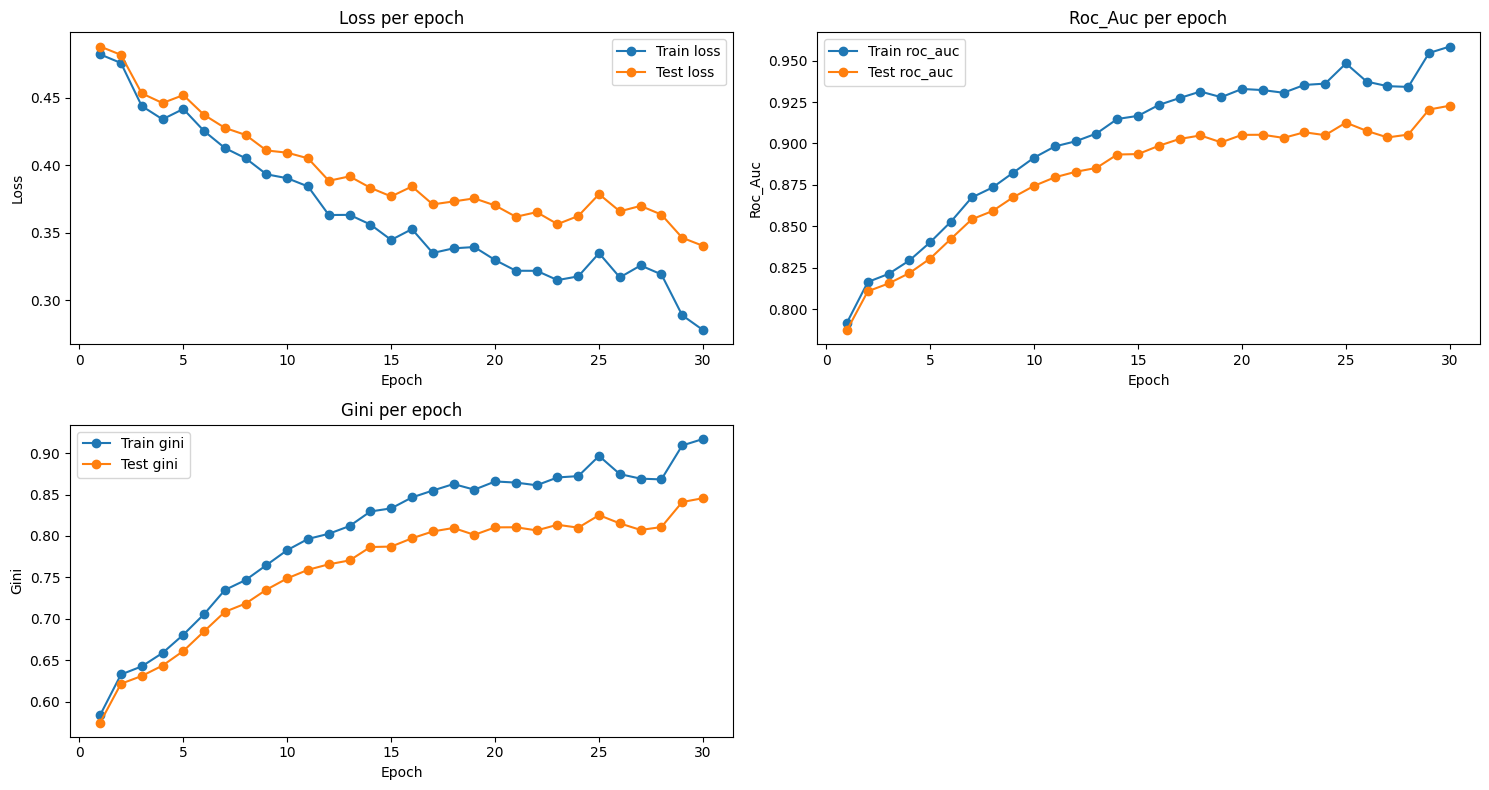

In [21]:
mlp_trainer.get_metrics_graphic()

In [22]:
roc_auc, avg_loss = mlp_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.925


## ResNet

### First Dataset

In [18]:
resnet_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    num_encoder="ple"
)

In [19]:
resnet_data.load_data()

Data downloaded successfully in the amount of 307511


In [21]:
resnet_dataset = resnet_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [22]:
dimensions = resnet_data.torch_tensors_dimensions()
dimensions

(1300, 248)

In [27]:
resnet = ResNet(
    input_dim=dimensions[0] + dimensions[1],
    num_blocks=1,
    main_dim=128,
    hidden_dim=256,
    output_dim=1,
    normalization='BatchNorm1d',
    activation='ReLu',
    dropout_first=0.5,
    dropout_second=0.5,
    skip_connection=True
)

In [28]:
resnet_trainer = TrainerModel(
    model=resnet, 
    dataset=resnet_dataset,
    exp_name="resnet",
    type_model="NN"
)

In [29]:
resnet_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7443 Train Loss: 0.2613
   Test ROC-AUC: 0.7408 Test Loss: 0.2629
2) Train ROC-AUC: 0.7508 Train Loss: 0.2547
   Test ROC-AUC: 0.7434 Test Loss: 0.2572
3) Train ROC-AUC: 0.7527 Train Loss: 0.2579
   Test ROC-AUC: 0.7443 Test Loss: 0.2609
4) Train ROC-AUC: 0.7528 Train Loss: 0.2503
   Test ROC-AUC: 0.7401 Test Loss: 0.2538
5) Train ROC-AUC: 0.7582 Train Loss: 0.2489
   Test ROC-AUC: 0.7434 Test Loss: 0.2531
6) Train ROC-AUC: 0.7607 Train Loss: 0.2497
   Test ROC-AUC: 0.7452 Test Loss: 0.2544
7) Train ROC-AUC: 0.7622 Train Loss: 0.246
   Test ROC-AUC: 0.7442 Test Loss: 0.2513
8) Train ROC-AUC: 0.7646 Train Loss: 0.2483
   Test ROC-AUC: 0.7446 Test Loss: 0.2545
9) Train ROC-AUC: 0.7669 Train Loss: 0.2455
   Test ROC-AUC: 0.7438 Test Loss: 0.2519
10) Train ROC-AUC: 0.7678 Train Loss: 0.2443
   Test ROC-AUC: 0.7436 Test Loss: 0.2516
11) Train ROC-AUC: 0.772 Train Loss: 0.2434
   Test ROC-AUC: 0.7438 Test Loss: 0.2515
12) Train ROC-AUC: 0.7743 Train Loss: 0.2422
   Test R

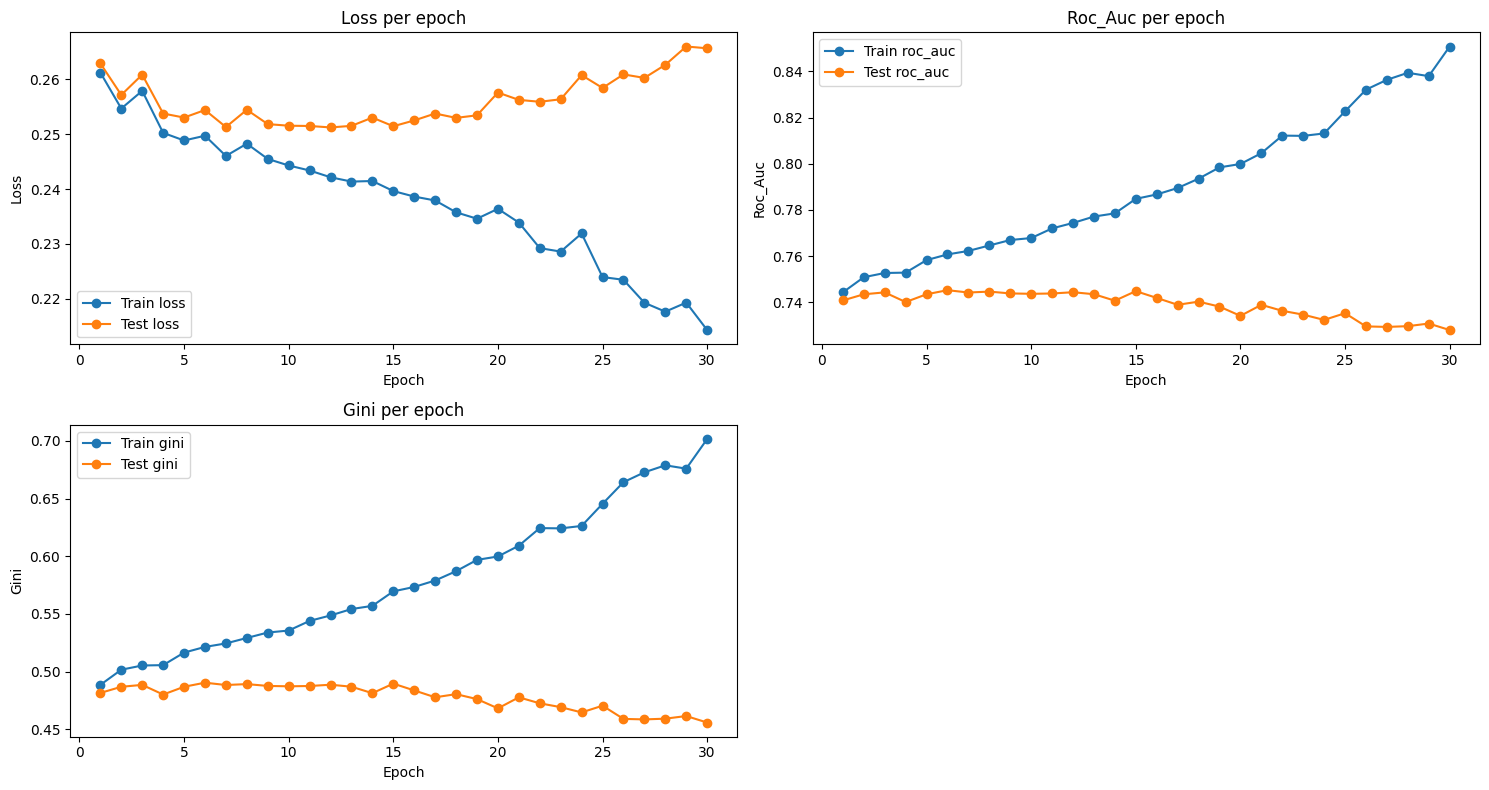

In [30]:
resnet_trainer.get_metrics_graphic()

In [31]:
roc_auc, avg_loss = resnet_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.727


### Second Dataset

In [23]:
resnet_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    num_encoder="ple"
)

In [24]:
resnet_data.load_data()

Data downloaded successfully in the amount of 51685


In [25]:
resnet_dataset = resnet_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [26]:
dimensions = resnet_data.torch_tensors_dimensions()
dimensions

(500, 11709)

In [27]:
resnet = ResNet(
    input_dim=dimensions[0] + dimensions[1],
    num_blocks=1,
    main_dim=128,
    hidden_dim=256,
    output_dim=1,
    normalization='BatchNorm1d',
    activation='ReLu',
    dropout_first=0.5,
    dropout_second=0.5,
    skip_connection=True
)

In [28]:
resnet_trainer = TrainerModel(
    model=resnet, 
    dataset=resnet_dataset,
    exp_name="resnet",
    type_model="NN"
)

In [29]:
resnet_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.8771 Train Loss: 0.4108
   Test ROC-AUC: 0.8614 Test Loss: 0.4296
2) Train ROC-AUC: 0.921 Train Loss: 0.3185
   Test ROC-AUC: 0.8956 Test Loss: 0.3656
3) Train ROC-AUC: 0.9639 Train Loss: 0.2276
   Test ROC-AUC: 0.9231 Test Loss: 0.3157
4) Train ROC-AUC: 0.9654 Train Loss: 0.4445
   Test ROC-AUC: 0.9171 Test Loss: 0.5327
5) Train ROC-AUC: 0.9768 Train Loss: 0.1789
   Test ROC-AUC: 0.9284 Test Loss: 0.3107
6) Train ROC-AUC: 0.9794 Train Loss: 0.1885
   Test ROC-AUC: 0.9317 Test Loss: 0.3179
7) Train ROC-AUC: 0.9742 Train Loss: 0.3841
   Test ROC-AUC: 0.9147 Test Loss: 0.536
8) Train ROC-AUC: 0.9801 Train Loss: 0.2044
   Test ROC-AUC: 0.9278 Test Loss: 0.3427
9) Train ROC-AUC: 0.9798 Train Loss: 0.2142
   Test ROC-AUC: 0.9234 Test Loss: 0.3698
10) Train ROC-AUC: 0.968 Train Loss: 0.4681
   Test ROC-AUC: 0.8983 Test Loss: 0.6403
11) Train ROC-AUC: 0.9815 Train Loss: 0.1999
   Test ROC-AUC: 0.9222 Test Loss: 0.3562
12) Train ROC-AUC: 0.983 Train Loss: 0.1563
   Test ROC

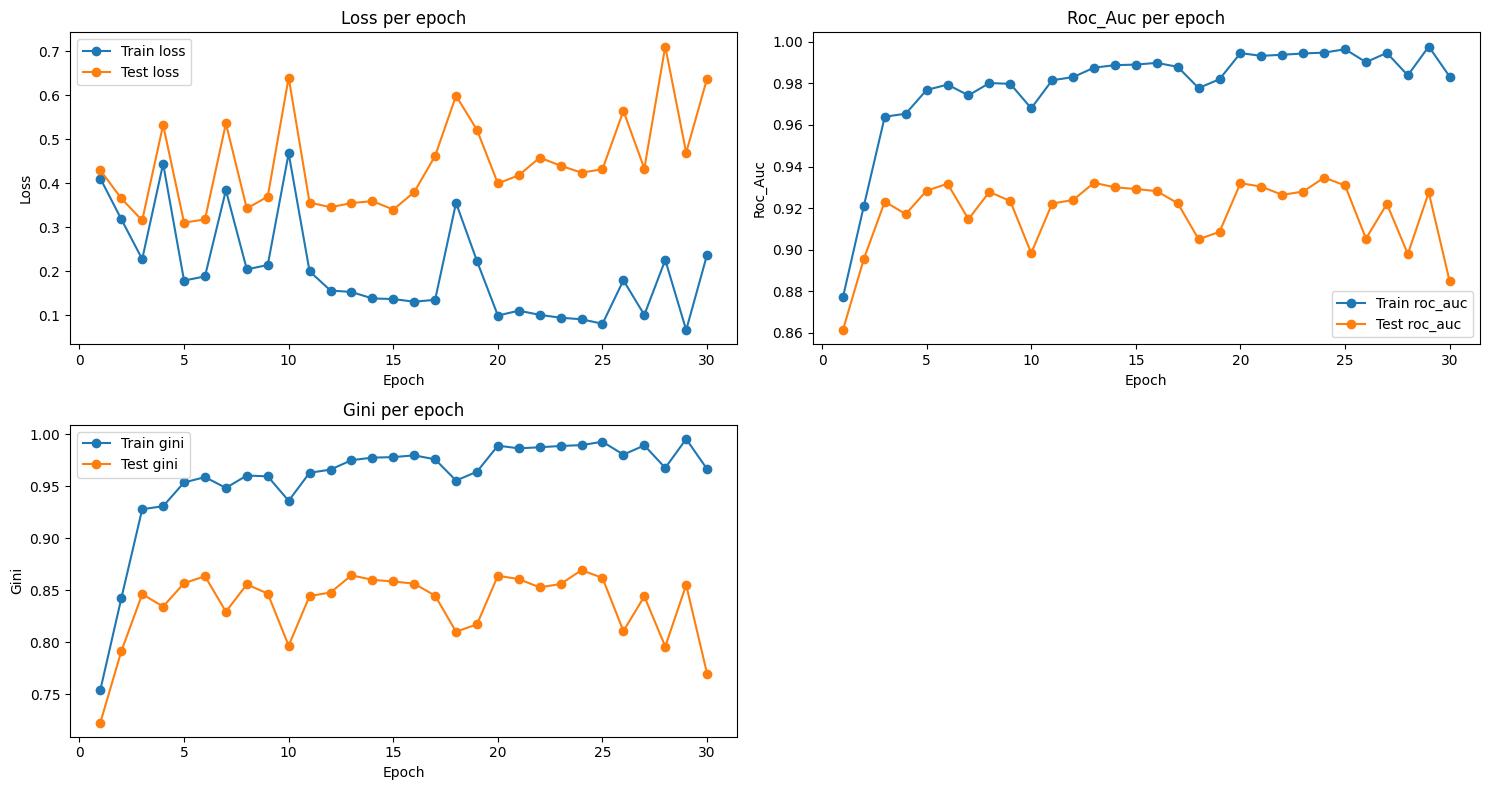

In [30]:
resnet_trainer.get_metrics_graphic()

## FT-Transformer

### First Dataset

In [20]:
transformer_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    type_model="Transformer",
    cat_encoder="ordinal",
    num_encoder=None
)

In [11]:
transformer_data.load_data()

Data downloaded successfully in the amount of 307511


In [12]:
transformer_dataset = transformer_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [13]:
dimensions = transformer_data.torch_tensors_dimensions()
dimensions

(65, 52)

In [14]:
cat_cardinalities = transformer_data.cat_cardinalities
len(cat_cardinalities)

52

In [15]:
transformer = FTTransformer.make_default(
    n_num_features=dimensions[0],
    cat_cardinalities=cat_cardinalities,
    last_layer_query_idx=[-1],
    d_out=1
)

In [17]:
FTTransformer_trainer = TrainerModel(
    model=transformer, 
    dataset=transformer_dataset,
    exp_name="transformer",
    type_model="Transformer"
)

Проблема с кат-фичами (в валидейте есть что-то чего нет в тесте, из-за этого код падает)

In [18]:
FTTransformer_trainer.train(25, 64)

Training:   0%|          | 0/25 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7467 Train Loss: 0.2505
   Test ROC-AUC: 0.7425 Test Loss: 0.2525


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (25,) and (1,)

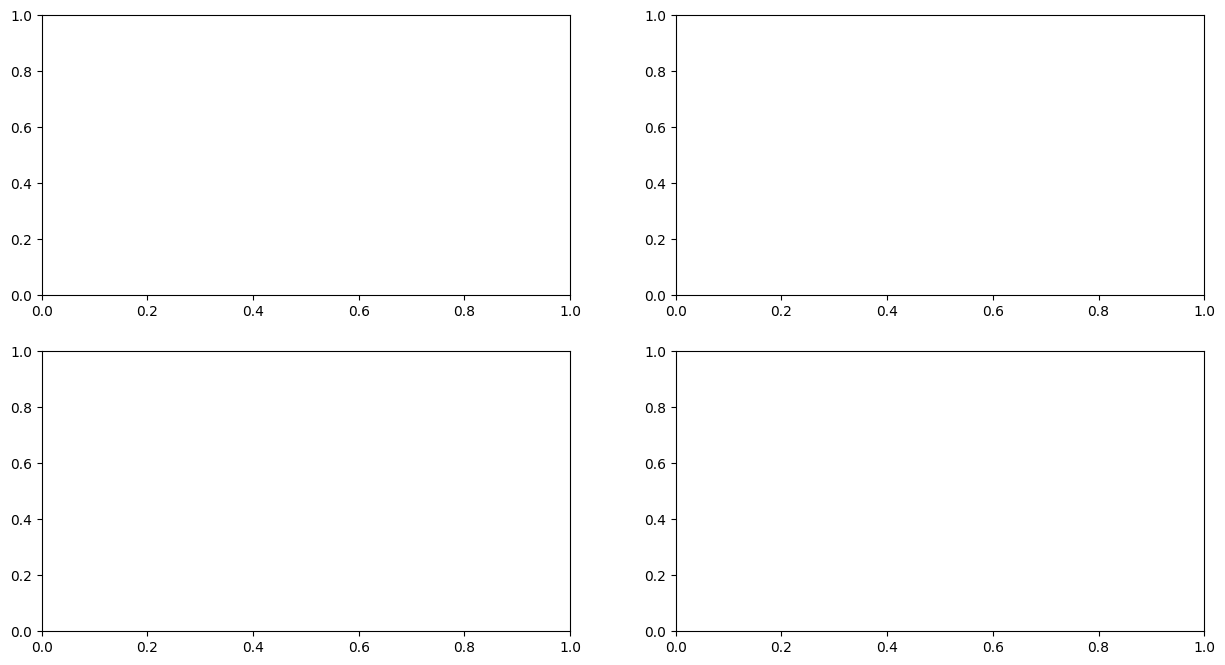

In [19]:
FTTransformer_trainer.get_metrics_graphic()

### Second Dataset

In [54]:
transformer_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    type_model="Transformer",
    cat_encoder="ordinal",
    num_encoder=None
)

In [55]:
transformer_data.load_data()

Data downloaded successfully in the amount of 51685


In [56]:
transformer_dataset = transformer_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [57]:
dimensions = transformer_data.torch_tensors_dimensions()
dimensions

(25, 7)

In [58]:
cat_cardinalities = transformer_data.cat_cardinalities
len(cat_cardinalities)

7

In [59]:
transformer = FTTransformer(
    n_cont_features=dimensions[0],
    cat_cardinalities=cat_cardinalities,
    d_out=1,
    n_blocks=3,
    d_block=192,
    attention_n_heads=8,
    attention_dropout=0.2,
    ffn_d_hidden=None,
    ffn_d_hidden_multiplier=4/3,
    ffn_dropout=0.1,
    residual_dropout=0.0
)

In [60]:
FTTransformer_trainer = TrainerModel(
    model=transformer, 
    dataset=transformer_dataset,
    exp_name="transformer",
    type_model="Transformer"
)

In [62]:
FTTransformer_trainer.train(9, 32)

Training:   0%|          | 0/9 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.9562 Train Loss: 0.252
   Test ROC-AUC: 0.9163 Test Loss: 0.3215
2) Train ROC-AUC: 0.9739 Train Loss: 0.1875
   Test ROC-AUC: 0.9278 Test Loss: 0.3133
3) Train ROC-AUC: 0.9822 Train Loss: 0.1504
   Test ROC-AUC: 0.927 Test Loss: 0.3255
4) Train ROC-AUC: 0.9833 Train Loss: 0.1406
   Test ROC-AUC: 0.929 Test Loss: 0.3606
5) Train ROC-AUC: 0.9862 Train Loss: 0.1448
   Test ROC-AUC: 0.922 Test Loss: 0.3631
6) Train ROC-AUC: 0.9893 Train Loss: 0.1197
   Test ROC-AUC: 0.9309 Test Loss: 0.4311
7) Train ROC-AUC: 0.9914 Train Loss: 0.1085
   Test ROC-AUC: 0.9309 Test Loss: 0.4095
8) Train ROC-AUC: 0.9926 Train Loss: 0.1002
   Test ROC-AUC: 0.9283 Test Loss: 0.4371
9) Train ROC-AUC: 0.9945 Train Loss: 0.0868
   Test ROC-AUC: 0.9242 Test Loss: 0.5229


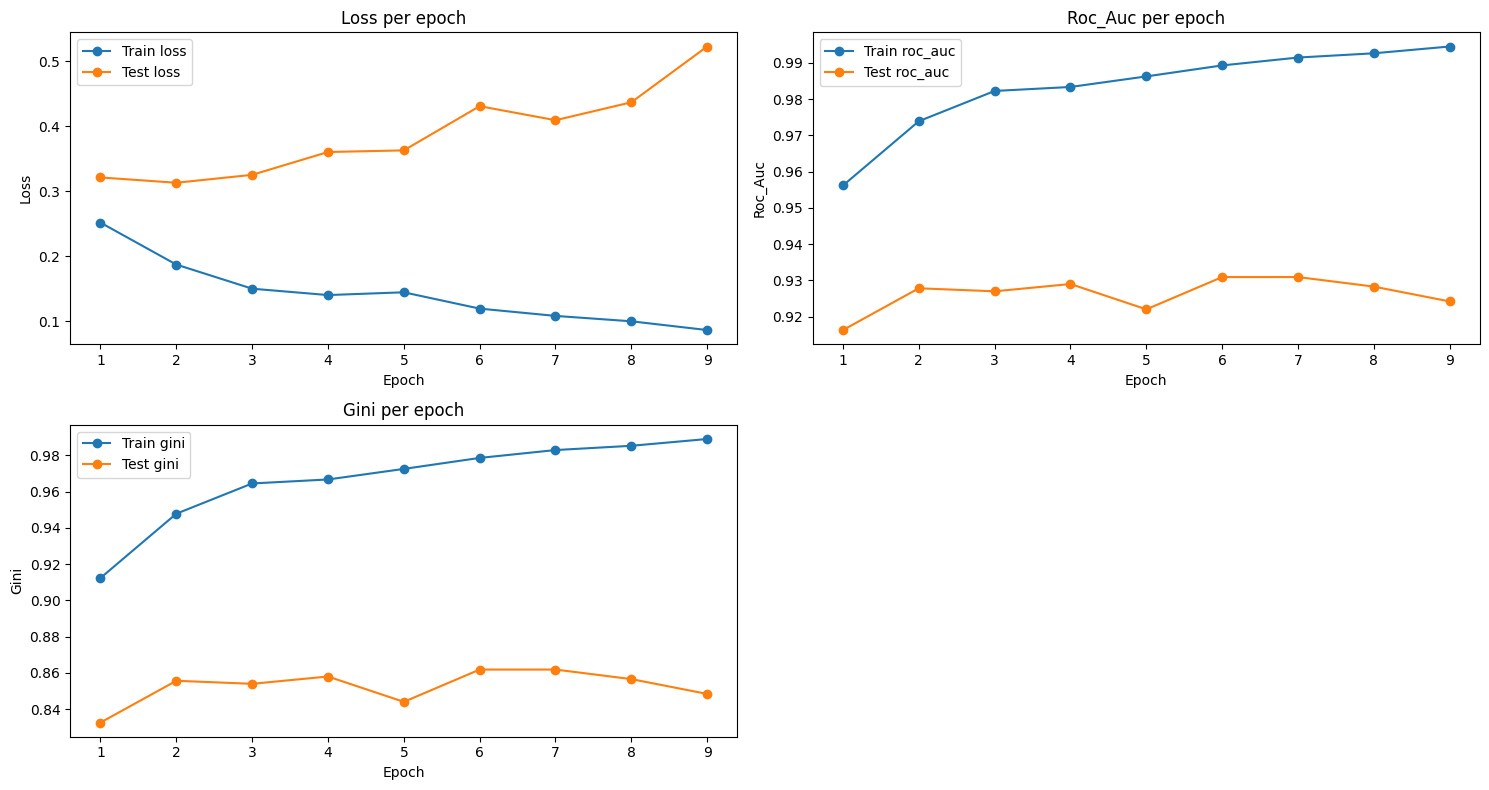

In [64]:
FTTransformer_trainer.get_metrics_graphic()

In [63]:
roc_auc, avg_loss = FTTransformer_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.943


## MLP-encoder Transformer

### First Dataset

In [47]:
mlp_transformer_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    type_model="MLP-Transformer",
    cat_encoder='ordinal',
    num_encoder=None
)

In [48]:
mlp_transformer_data.load_data()

Data downloaded successfully in the amount of 307511


In [49]:
mlp_transformer_dataset = mlp_transformer_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [50]:
model_config = {
    'tf_dropout_rates': [0.3]*6,
    'ff_dropout_rates': [0.3]*6,
    'embedding_dim': 12,
    'num_transformer_blocks': 6,
    'num_heads': 3,
    'mlp_dropout_rates': [0.3, 0.3],
    'mlp_hidden_units_factors': [2, 1]
}

model = MlpEncoderTransformer(
    categorical_features=mlp_transformer_data.cat_features,
    numerical_features=mlp_transformer_data.num_features,
    lookup_layers=mlp_transformer_data.lookup_layers,
    **model_config
)

In [52]:
trainer = TrainerModel(
    model=model,
    dataset=mlp_transformer_dataset,
    exp_name="mlp_encoder_transformer_1",
    type_model="MLP-Transformer",
    lr=3e-4,
    weight_decay=0.005
)

In [53]:
trainer.train(n_epoch=50, batch_size=32)

Training:   0%|          | 0/50 [elapsed: 00:00 remaining: ?]

KeyboardInterrupt: 

### Second Dataset

In [39]:
mlp_transformer_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    type_model="MLP-Transformer",
    cat_encoder='ordinal',
    num_encoder=None
)

In [40]:
mlp_transformer_data.load_data()

Data downloaded successfully in the amount of 51685


In [41]:
mlp_transformer_dataset = mlp_transformer_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [42]:
model_config = {
    'tf_dropout_rates': [0.3]*6,
    'ff_dropout_rates': [0.3]*6,
    'embedding_dim': 12,
    'num_transformer_blocks': 6,
    'num_heads': 3,
    'mlp_dropout_rates': [0.3, 0.3],
    'mlp_hidden_units_factors': [2, 1]
}

model = MlpEncoderTransformer(
    categorical_features=mlp_transformer_data.cat_features,
    numerical_features=mlp_transformer_data.num_features,
    lookup_layers=mlp_transformer_data.lookup_layers,
    **model_config
)

In [43]:
trainer = TrainerModel(
    model=model,
    dataset=mlp_transformer_dataset,
    exp_name="mlp_encoder_transformer",
    type_model="MLP-Transformer",
    lr=3e-4,
    weight_decay=0.005
)

In [44]:
trainer.train(n_epoch=50, batch_size=32)

Training:   0%|          | 0/50 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7297 Train Loss: 0.5166
   Test ROC-AUC: 0.7303 Test Loss: 0.5175
2) Train ROC-AUC: 0.7542 Train Loss: 0.5059
   Test ROC-AUC: 0.7467 Test Loss: 0.5088
3) Train ROC-AUC: 0.7618 Train Loss: 0.5002
   Test ROC-AUC: 0.7521 Test Loss: 0.5039
4) Train ROC-AUC: 0.7699 Train Loss: 0.4947
   Test ROC-AUC: 0.7652 Test Loss: 0.4983
5) Train ROC-AUC: 0.7728 Train Loss: 0.4935
   Test ROC-AUC: 0.767 Test Loss: 0.4975
6) Train ROC-AUC: 0.776 Train Loss: 0.4906
   Test ROC-AUC: 0.7702 Test Loss: 0.4958
7) Train ROC-AUC: 0.7793 Train Loss: 0.4888
   Test ROC-AUC: 0.7688 Test Loss: 0.4963
8) Train ROC-AUC: 0.7823 Train Loss: 0.4875
   Test ROC-AUC: 0.7763 Test Loss: 0.4945
9) Train ROC-AUC: 0.7923 Train Loss: 0.4793
   Test ROC-AUC: 0.7756 Test Loss: 0.4911
10) Train ROC-AUC: 0.7981 Train Loss: 0.4743
   Test ROC-AUC: 0.785 Test Loss: 0.4861
11) Train ROC-AUC: 0.8105 Train Loss: 0.4639
   Test ROC-AUC: 0.7892 Test Loss: 0.482
12) Train ROC-AUC: 0.821 Train Loss: 0.4537
   Test ROC-

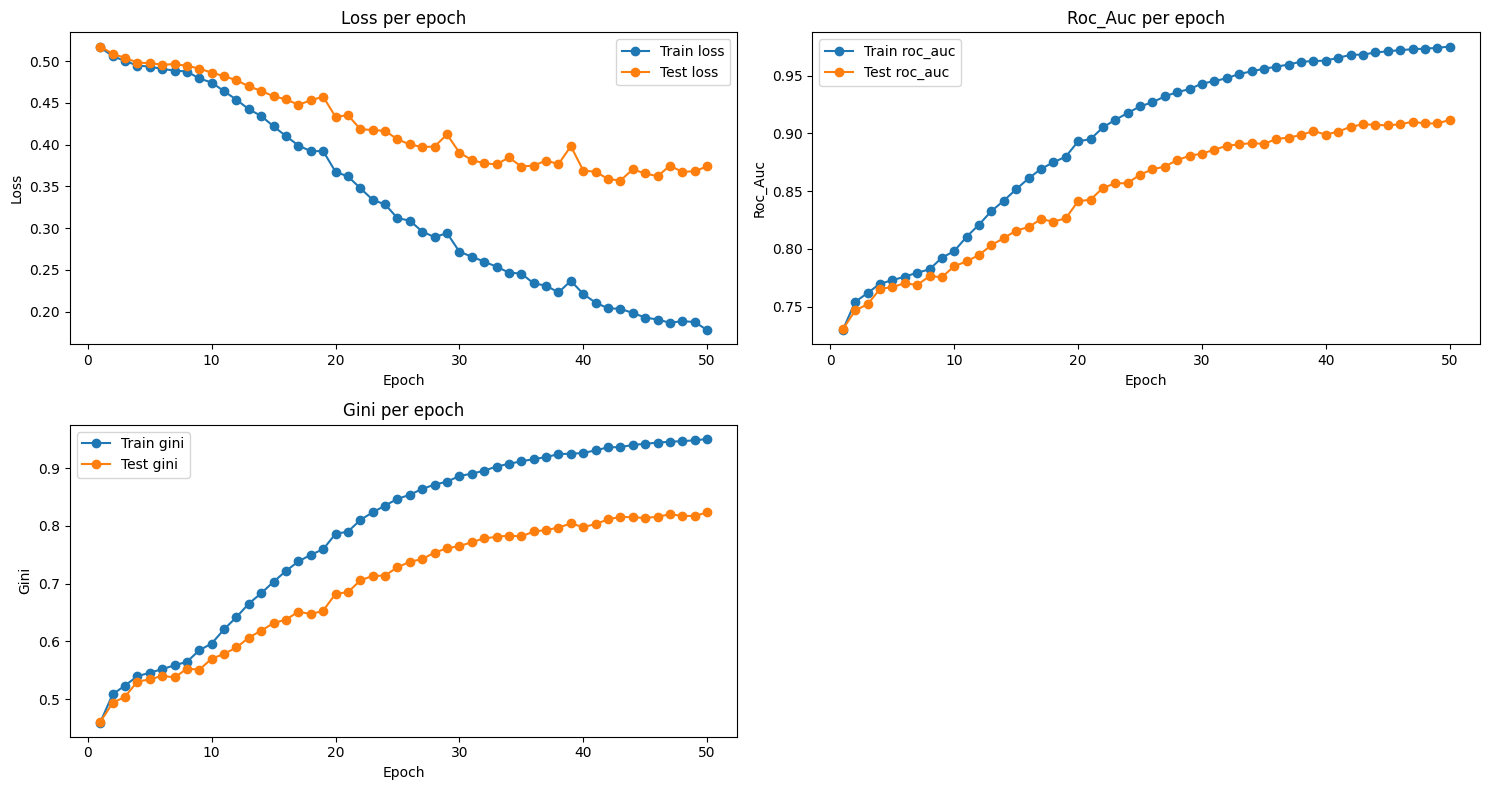

In [45]:
trainer.get_metrics_graphic()

In [46]:
roc_auc, avg_loss = trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.928


# Сравнение энкодеров на примере MLP

In [44]:
exp_path = "Test_encoders/"

## Without Encoding

### First Dataset

In [26]:
none_mlp_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    num_encoder=None
)

In [27]:
none_mlp_data.load_data()

Data downloaded successfully in the amount of 307511


In [28]:
none_mlp_dataset = none_mlp_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [29]:
dimensions = none_mlp_data.torch_tensors_dimensions()
dimensions

(65, 248)

In [30]:
none_mlp = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [31]:
none_trainer = TrainerModel(
    model=none_mlp,
    dataset=none_mlp_dataset, 
    exp_name=exp_path + "first_dataset/without_encoder", 
    type_model="NN"
)

In [32]:
none_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7429 Train Loss: 0.2568
   Test ROC-AUC: 0.7411 Test Loss: 0.2598
2) Train ROC-AUC: 0.7455 Train Loss: 0.2518
   Test ROC-AUC: 0.7416 Test Loss: 0.2547
3) Train ROC-AUC: 0.7486 Train Loss: 0.2539
   Test ROC-AUC: 0.7433 Test Loss: 0.2565
4) Train ROC-AUC: 0.7486 Train Loss: 0.2542
   Test ROC-AUC: 0.7434 Test Loss: 0.2568
5) Train ROC-AUC: 0.7508 Train Loss: 0.2527
   Test ROC-AUC: 0.7446 Test Loss: 0.256
6) Train ROC-AUC: 0.7514 Train Loss: 0.253
   Test ROC-AUC: 0.7436 Test Loss: 0.2562
7) Train ROC-AUC: 0.7525 Train Loss: 0.2542
   Test ROC-AUC: 0.7433 Test Loss: 0.2573
8) Train ROC-AUC: 0.7537 Train Loss: 0.2556
   Test ROC-AUC: 0.7431 Test Loss: 0.259
9) Train ROC-AUC: 0.7536 Train Loss: 0.2534
   Test ROC-AUC: 0.7436 Test Loss: 0.2566
10) Train ROC-AUC: 0.7552 Train Loss: 0.2516
   Test ROC-AUC: 0.743 Test Loss: 0.2564
11) Train ROC-AUC: 0.756 Train Loss: 0.2533
   Test ROC-AUC: 0.7446 Test Loss: 0.257
12) Train ROC-AUC: 0.7569 Train Loss: 0.2524
   Test ROC-A

In [33]:
roc_auc, avg_loss = none_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.744


### Second Dataset

In [49]:
none_mlp_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    num_encoder=None
)

In [50]:
none_mlp_data.load_data()

Data downloaded successfully in the amount of 51685


In [51]:
none_mlp_dataset = none_mlp_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [52]:
dimensions = none_mlp_data.torch_tensors_dimensions()
dimensions

(25, 11726)

In [53]:
none_mlp = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [54]:
none_trainer = TrainerModel(
    model=none_mlp,
    dataset=none_mlp_dataset, 
    exp_name=exp_path + "second_dataset/without_encoder",
    type_model="NN"
)

In [55]:
none_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7954 Train Loss: 0.5132
   Test ROC-AUC: 0.7898 Test Loss: 0.5157
2) Train ROC-AUC: 0.8235 Train Loss: 0.4856
   Test ROC-AUC: 0.809 Test Loss: 0.4937
3) Train ROC-AUC: 0.8835 Train Loss: 0.4399
   Test ROC-AUC: 0.8545 Test Loss: 0.4601
4) Train ROC-AUC: 0.9439 Train Loss: 0.3522
   Test ROC-AUC: 0.8983 Test Loss: 0.4006
5) Train ROC-AUC: 0.9649 Train Loss: 0.275
   Test ROC-AUC: 0.9133 Test Loss: 0.3495
6) Train ROC-AUC: 0.9731 Train Loss: 0.2401
   Test ROC-AUC: 0.9179 Test Loss: 0.3327
7) Train ROC-AUC: 0.9782 Train Loss: 0.2126
   Test ROC-AUC: 0.9197 Test Loss: 0.3237
8) Train ROC-AUC: 0.9825 Train Loss: 0.2017
   Test ROC-AUC: 0.9235 Test Loss: 0.3209
9) Train ROC-AUC: 0.9831 Train Loss: 0.176
   Test ROC-AUC: 0.9267 Test Loss: 0.3105
10) Train ROC-AUC: 0.9859 Train Loss: 0.1651
   Test ROC-AUC: 0.9239 Test Loss: 0.3151
11) Train ROC-AUC: 0.9874 Train Loss: 0.1505
   Test ROC-AUC: 0.9266 Test Loss: 0.3186
12) Train ROC-AUC: 0.9892 Train Loss: 0.1431
   Test RO

In [41]:
roc_auc, avg_loss = none_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.932


## Periodic Encoding

### First Dataset

In [42]:
periodic_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    num_encoder="periodic"
)

In [43]:
periodic_data.load_data()

Data downloaded successfully in the amount of 307511


In [44]:
periodic_dataset = periodic_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [45]:
dimensions = periodic_data.torch_tensors_dimensions()
dimensions

(390, 248)

In [46]:
mlp_periodic = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [47]:
periodic_trainer = TrainerModel(
    model=mlp_periodic, 
    dataset=periodic_dataset, 
    exp_name=exp_path + "first_dataset/periodic_encoder", 
    type_model="NN"
)

In [48]:
periodic_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.6553 Train Loss: 0.2782
   Test ROC-AUC: 0.6541 Test Loss: 0.2795
2) Train ROC-AUC: 0.6605 Train Loss: 0.2703
   Test ROC-AUC: 0.6577 Test Loss: 0.2719
3) Train ROC-AUC: 0.6607 Train Loss: 0.2712
   Test ROC-AUC: 0.654 Test Loss: 0.2731
4) Train ROC-AUC: 0.6665 Train Loss: 0.2694
   Test ROC-AUC: 0.6587 Test Loss: 0.2715
5) Train ROC-AUC: 0.6707 Train Loss: 0.2689
   Test ROC-AUC: 0.6572 Test Loss: 0.2717
6) Train ROC-AUC: 0.67 Train Loss: 0.2695
   Test ROC-AUC: 0.6529 Test Loss: 0.2724
7) Train ROC-AUC: 0.6752 Train Loss: 0.2691
   Test ROC-AUC: 0.6555 Test Loss: 0.2722
8) Train ROC-AUC: 0.6773 Train Loss: 0.2688
   Test ROC-AUC: 0.6528 Test Loss: 0.2724
9) Train ROC-AUC: 0.6835 Train Loss: 0.2683
   Test ROC-AUC: 0.6554 Test Loss: 0.2723
10) Train ROC-AUC: 0.6865 Train Loss: 0.2668
   Test ROC-AUC: 0.6546 Test Loss: 0.2718
11) Train ROC-AUC: 0.6924 Train Loss: 0.267
   Test ROC-AUC: 0.6518 Test Loss: 0.2723
12) Train ROC-AUC: 0.6954 Train Loss: 0.2661
   Test ROC

In [49]:
roc_auc, avg_loss = periodic_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.636


### Second Dataset

In [46]:
periodic_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    num_encoder="periodic"
)

In [47]:
periodic_data.load_data()

Data downloaded successfully in the amount of 51685


In [48]:
periodic_dataset = periodic_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [53]:
dimensions = periodic_data.torch_tensors_dimensions()
dimensions

(150, 11709)

In [54]:
mlp_periodic = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [55]:
periodic_trainer = TrainerModel(
    model=mlp_periodic, 
    dataset=periodic_dataset, 
    exp_name=exp_path + "second_dataset/periodic_encoder", 
    type_model="NN"
)

In [56]:
periodic_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7738 Train Loss: 0.4967
   Test ROC-AUC: 0.7666 Test Loss: 0.5042
2) Train ROC-AUC: 0.8167 Train Loss: 0.4606
   Test ROC-AUC: 0.806 Test Loss: 0.4714
3) Train ROC-AUC: 0.8328 Train Loss: 0.4376
   Test ROC-AUC: 0.819 Test Loss: 0.453
4) Train ROC-AUC: 0.8516 Train Loss: 0.4242
   Test ROC-AUC: 0.8332 Test Loss: 0.4436
5) Train ROC-AUC: 0.8749 Train Loss: 0.3984
   Test ROC-AUC: 0.8497 Test Loss: 0.4268
6) Train ROC-AUC: 0.9061 Train Loss: 0.3545
   Test ROC-AUC: 0.8751 Test Loss: 0.3969
7) Train ROC-AUC: 0.9325 Train Loss: 0.3094
   Test ROC-AUC: 0.8952 Test Loss: 0.3687
8) Train ROC-AUC: 0.9487 Train Loss: 0.2707
   Test ROC-AUC: 0.9074 Test Loss: 0.343
9) Train ROC-AUC: 0.9643 Train Loss: 0.2382
   Test ROC-AUC: 0.9195 Test Loss: 0.3176
10) Train ROC-AUC: 0.972 Train Loss: 0.2146
   Test ROC-AUC: 0.9225 Test Loss: 0.3082
11) Train ROC-AUC: 0.9757 Train Loss: 0.2077
   Test ROC-AUC: 0.9259 Test Loss: 0.3071
12) Train ROC-AUC: 0.9789 Train Loss: 0.1877
   Test ROC-

In [57]:
roc_auc, avg_loss = periodic_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.932


## PLE Encoding

### Fisrt Dataset

In [58]:
ple_data = PrepareTabularData(
    os_path="data/first_dataset/application_train.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="TARGET",
    num_encoder="ple"
)

In [59]:
ple_data.load_data()

Data downloaded successfully in the amount of 307511


In [60]:
ple_dataset = ple_data.prepare_dataset()

Train shape:    (246008, 118)
Test shape:     (43052, 118)
Validate shape: (18451, 118)


In [61]:
dimensions = ple_data.torch_tensors_dimensions()
dimensions

(1300, 248)

In [62]:
mlp_ple = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [63]:
ple_trainer = TrainerModel(
    model=mlp_ple, 
    dataset=ple_dataset, 
    exp_name=exp_path + "first_dataset/ple_encoder",
    type_model="NN"
)

In [64]:
ple_trainer.train(30, 128)

Training:   0%|          | 0/30 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.7386 Train Loss: 0.2994
   Test ROC-AUC: 0.7369 Test Loss: 0.3007
2) Train ROC-AUC: 0.7425 Train Loss: 0.2771
   Test ROC-AUC: 0.7395 Test Loss: 0.2785
3) Train ROC-AUC: 0.7431 Train Loss: 0.2669
   Test ROC-AUC: 0.7407 Test Loss: 0.268
4) Train ROC-AUC: 0.7385 Train Loss: 0.2627
   Test ROC-AUC: 0.736 Test Loss: 0.2641
5) Train ROC-AUC: 0.7444 Train Loss: 0.2586
   Test ROC-AUC: 0.7408 Test Loss: 0.26
6) Train ROC-AUC: 0.7446 Train Loss: 0.2575
   Test ROC-AUC: 0.7411 Test Loss: 0.2589
7) Train ROC-AUC: 0.7448 Train Loss: 0.2584
   Test ROC-AUC: 0.7414 Test Loss: 0.2598
8) Train ROC-AUC: 0.7453 Train Loss: 0.2584
   Test ROC-AUC: 0.7428 Test Loss: 0.2598
9) Train ROC-AUC: 0.7459 Train Loss: 0.2574
   Test ROC-AUC: 0.7422 Test Loss: 0.259
10) Train ROC-AUC: 0.7467 Train Loss: 0.2588
   Test ROC-AUC: 0.7424 Test Loss: 0.2604
11) Train ROC-AUC: 0.7465 Train Loss: 0.2563
   Test ROC-AUC: 0.7423 Test Loss: 0.258
12) Train ROC-AUC: 0.7456 Train Loss: 0.2574
   Test ROC-A

In [65]:
roc_auc, avg_loss = ple_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.753


### Second Dataset

In [38]:
ple_data = PrepareTabularData(
    os_path="data/second_dataset/application.csv", 
    test_size=0.2,
    val_size=0.3,
    target_column="Credit_Score",
    num_encoder="ple"
)

In [39]:
ple_data.load_data()

Data downloaded successfully in the amount of 51685


In [40]:
ple_dataset = ple_data.prepare_dataset()

Train shape:    (41348, 33)
Test shape:     (7235, 33)
Validate shape: (3102, 33)


In [41]:
dimensions = ple_data.torch_tensors_dimensions()
dimensions

(500, 11726)

In [42]:
mlp_ple = MLP(
    input_dim=dimensions[0] + dimensions[1],
    hidden_layers=[256, 128, 64, 4],
    output_dim=1,
    activation="ReLu",
    dropout_rate=0.5,
)

In [45]:
ple_trainer = TrainerModel(
    model=mlp_ple, 
    dataset=ple_dataset, 
    exp_name=exp_path + "second_dataset/ple_encoder",
    type_model="NN"
)

In [81]:
ple_trainer.train(45, 128)

Training:   0%|          | 0/45 [elapsed: 00:00 remaining: ?]

1) Train ROC-AUC: 0.8037 Train Loss: 0.4747
   Test ROC-AUC: 0.7995 Test Loss: 0.4825
2) Train ROC-AUC: 0.8233 Train Loss: 0.4549
   Test ROC-AUC: 0.8179 Test Loss: 0.463
3) Train ROC-AUC: 0.8399 Train Loss: 0.4478
   Test ROC-AUC: 0.8318 Test Loss: 0.457
4) Train ROC-AUC: 0.8528 Train Loss: 0.4286
   Test ROC-AUC: 0.8422 Test Loss: 0.441
5) Train ROC-AUC: 0.8631 Train Loss: 0.4219
   Test ROC-AUC: 0.8505 Test Loss: 0.4358
6) Train ROC-AUC: 0.8714 Train Loss: 0.4195
   Test ROC-AUC: 0.8592 Test Loss: 0.4371
7) Train ROC-AUC: 0.8819 Train Loss: 0.4054
   Test ROC-AUC: 0.867 Test Loss: 0.422
8) Train ROC-AUC: 0.8861 Train Loss: 0.4059
   Test ROC-AUC: 0.8705 Test Loss: 0.423
9) Train ROC-AUC: 0.8906 Train Loss: 0.394
   Test ROC-AUC: 0.8735 Test Loss: 0.4162
10) Train ROC-AUC: 0.8961 Train Loss: 0.3812
   Test ROC-AUC: 0.8796 Test Loss: 0.4014
11) Train ROC-AUC: 0.905 Train Loss: 0.3716
   Test ROC-AUC: 0.8859 Test Loss: 0.3957
12) Train ROC-AUC: 0.9051 Train Loss: 0.3647
   Test ROC-AUC

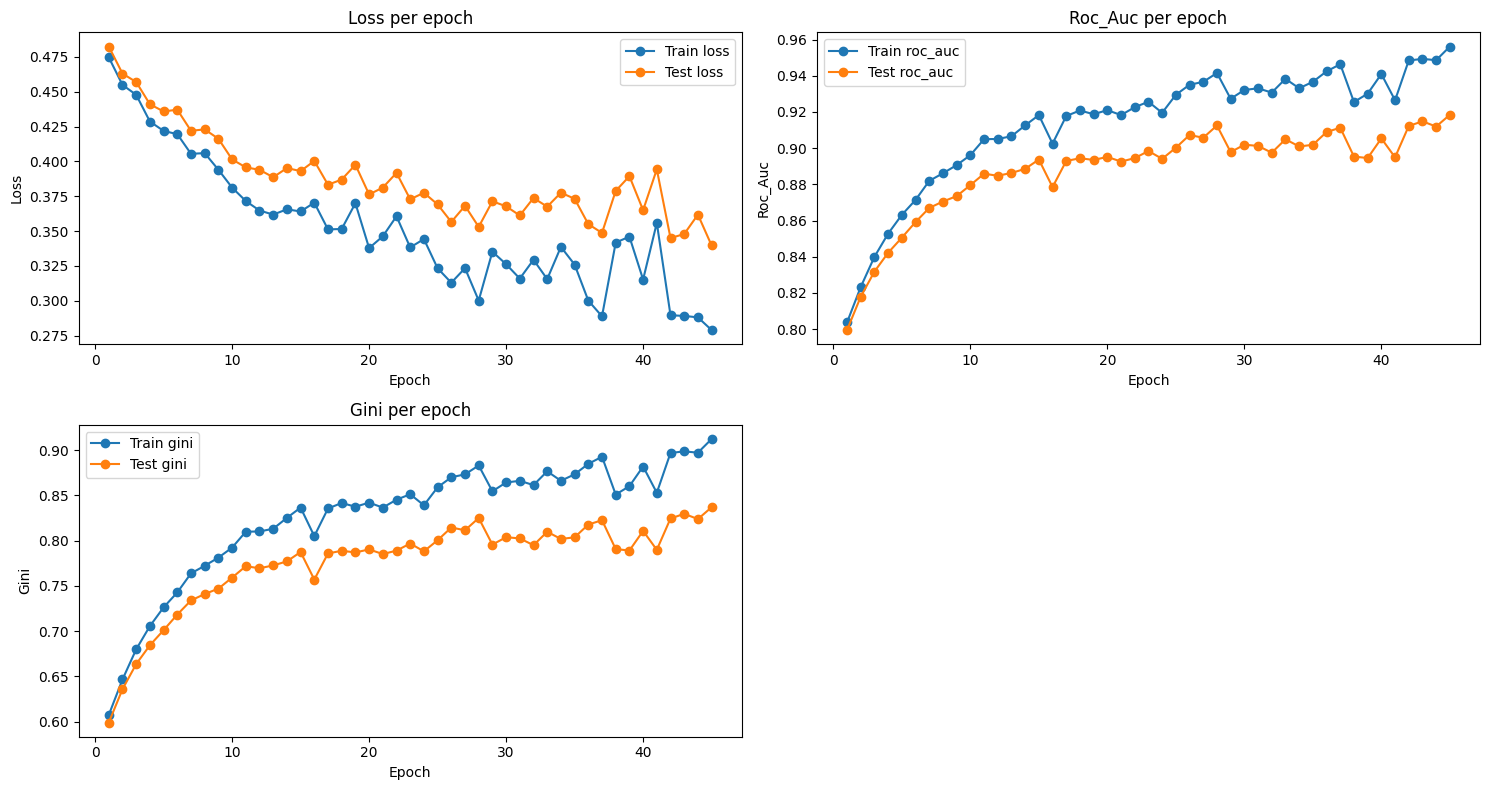

In [83]:
ple_trainer.get_metrics_graphic()

In [84]:
roc_auc, avg_loss = ple_trainer.evaluate_model('val')

print(f"Итоговый ROC-AUC на валидационном датасете: {round(roc_auc, 3)}")

Итоговый ROC-AUC на валидационном датасете: 0.917
